In [13]:
import numpy as np
import matplotlib.pyplot as plt

Define simple neural network for input $\mathbf{x} \in \mathbb{R}^d$

First, apply linear layer:
$$
    \mathbf{z} = W_1 \mathbf{x} + \mathbf{b}_1
$$
where $W_1 \in \mathbb{R}^{k \times d}$ and $\mathbf{b}_1 \in \mathbb{R}^{k}$, and $\mathbf{z} \in \mathbb{R}^{k}$. 

Next, put $\mathbf{z}$ through an activation function:
$$
    \mathbf{h} = \text{ReLU}(\mathbf{z})
$$
Apply second linear layer:
$$
    \mathbf{y} = W_2 \mathbf{h} + \mathbf{b}_2
$$
where $W_2 \in \mathbb{R}^{m \times k}$ and $\mathbf{b}_2 \in \mathbb{R}^{m}$, and $\mathbf{y} \in \mathbb{R}^{m}$. 

The trainable network parameters are: $W_1, W_2, \mathbf{b}_1, \mathbf{b}_2$

In [47]:
d = 3
k = 5
m = 2

W1 = np.random.randn(k, d)
b1 = np.random.randn(k, 1)

W2 = np.random.randn(m, k)
b2 = np.random.randn(m, 1)

x = np.random.randn(d, 1)

relu = lambda x: (x > 0)*x
d_relu = lambda x: (x > 0)*1

z = W1 @ x + b1
h = relu(z)
y = W2 @ h + b2

y.shape

(2, 1)

Differentiate from $\mathbf{y}$ back to each parameter

Derivatives with respect to the second layer parameters $W_2, \mathbf{b}_2$:
$$
    \dfrac{\partial \mathbf{y}}{\partial W_2} = \dfrac{\partial \mathbf{y}}{\partial \mathbf{y}} \mathbf{h}^T = \mathbf{1}_{m \times 1} \mathbf{h}^T
$$
$$
    \dfrac{\partial \mathbf{y}}{\partial \mathbf{b}_2} = \dfrac{\partial \mathbf{y}}{\partial \mathbf{y}} = \mathbf{1}_{m \times 1}
$$
where $\mathbf{1}_{m \times 1}$ is a column vector of all ones that has $m$ rows. 

Derivatives with respect to the first layer parameters $W_1, \mathbf{b}_1$:
$$
    \dfrac{\partial \mathbf{y}}{\partial W_1} = \dfrac{\partial \mathbf{y}}{\partial \mathbf{y}} \dfrac{\partial \mathbf{y}}{\partial \mathbf{h}} \dfrac{\partial \mathbf{h}}{\partial \mathbf{z}} \dfrac{\partial \mathbf{z}}{\partial W_1} = ((W_2^T  \mathbf{1}_{m \times 1}) \odot \text{ReLU}'(\mathbf{z})) \mathbf{x}^T
$$
$$
    \dfrac{\partial \mathbf{y}}{\partial \mathbf{b}_2} = \dfrac{\partial \mathbf{y}}{\partial \mathbf{y}} \dfrac{\partial \mathbf{y}}{\partial \mathbf{h}} \dfrac{\partial \mathbf{h}}{\partial \mathbf{z}} \dfrac{\partial \mathbf{z}}{\partial \mathbf{b}_2} = ((W_2^T  \mathbf{1}_{m \times 1}) \odot \text{ReLU}'(\mathbf{z}))
$$

where $\odot$ denotes the element-wise Hadamard product. 

In [48]:
dy_y = np.ones_like(y)

dy_W2 = dy_y @ h.T
dy_b2 = dy_y

dy_h = W2.T @ dy_y
dh_z = d_relu(z)

dy_W1 = (dy_h * dh_z) @ x.T
dy_b1 = (dy_h * dh_z)


dy_W2.shape, dy_b2.shape, dy_h.shape, dh_z.shape, dy_W1.shape, dy_b1.shape

((2, 5), (2, 1), (5, 1), (5, 1), (5, 3), (5, 1))

In [50]:
import torch

W1_t = torch.from_numpy(W1).requires_grad_()
b1_t = torch.from_numpy(b1).requires_grad_()

W2_t = torch.from_numpy(W2).requires_grad_()
b2_t = torch.from_numpy(b2).requires_grad_()

x_t = torch.from_numpy(x)

y_t = W2_t @ torch.relu(W1_t @ x_t + b1_t) + b2_t

y_t.backward(torch.ones_like(y_t))

torch_grads = [W1_t, b1_t, W2_t, b2_t]
numpy_grads = [dy_W1, dy_b1, dy_W2, dy_b2]

[np.isclose(t.grad.detach().numpy(), n) for t, n in zip(torch_grads, numpy_grads)]

[array([[ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True],
        [ True,  True,  True]]),
 array([[ True],
        [ True],
        [ True],
        [ True],
        [ True]]),
 array([[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True]]),
 array([[ True],
        [ True]])]

## Extension of Micrograd to simple matrix operations

In [5]:

class Tensor:

    def __init__(self, data: np.ndarray, _children=(), _op='', requires_grad=True):
        self.data = data
        self.grad = np.zeros_like(data, dtype='float')
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
        self.requires_grad = requires_grad

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other, requires_grad=False)
        out_requires_grad = (self.requires_grad or other.requires_grad)
        out = Tensor(self.data + other.data, (self, other), '+', requires_grad=out_requires_grad)

        def _backward():
            if self.requires_grad: self.grad += out.grad
            if other.requires_grad: other.grad += out.grad
        out._backward = _backward

        return out
    
    def broadcast_to(self, other_shape):

        out = Tensor(np.broadcast_to(self.data, other_shape), (self,), _op='Broadcast')
        
        def _backward():
            if self.requires_grad:
                m, n = self.data.shape
                match (m, n):
                    case (1, 1):
                        self.grad += out.grad.sum(axis=(0, 1))
                    case (1, _):
                        self.grad += out.grad.sum(axis=0)
                    case (_, 1):    
                        self.grad += out.grad.sum(axis=1)
                    case (_, _):
                        self.grad += out.grad

        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other, requires_grad=False)
        out_requires_grad = (self.requires_grad or other.requires_grad)
        out = Tensor(self.data * other.data, (self, other), '*', requires_grad=out_requires_grad)

        def _backward():
            # print(other.grad.shape, self.data.shape, out.grad.shape)
            if self.requires_grad: self.grad += other.data * out.grad
            if other.requires_grad: other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __matmul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other, requires_grad=False)
        out_requires_grad = (self.requires_grad or other.requires_grad)
        out = Tensor(self.data @ other.data, (self, other), '@', requires_grad=out_requires_grad)

        def _backward():
            # print(self.grad.shape, out.data.shape, out.grad.shape, other.data.shape)
            if self.requires_grad: self.grad += out.grad @ other.data.T 
            if other.requires_grad: other.grad += self.data.T @ out.grad 
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Tensor(self.data**other, (self,), f'**{other}')

        def _backward():
            if self.requires_grad: self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Tensor(np.where(self.data < 0, 0, self.data), (self,), 'ReLU')

        def _backward():
            if self.requires_grad: self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def sigmoid(self):
        out = Tensor(1.0/(1.0+np.exp(-self.data)), (self,), 'Sigmoid')

        def _backward():
            if self.requires_grad: self.grad += (1.0 - out.data) * out.data * out.grad
        out._backward = _backward

        return out
    
    def sum(self, axis):
        out = Tensor(self.data.sum(axis=axis), (self,), 'Sum')

        def _backward():
            if self.requires_grad: self.grad += out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = np.ones_like(self.data)
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * Tensor(np.array([[-1]]), requires_grad=False)

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Tensor(\ndata:\n{self.data}, \ngrad:\n{self.grad}\n)"

In [6]:
a = np.random.randn(3, 2)
b = np.random.randn(1, 2)

In [7]:
w = Tensor(a)
x = Tensor(b)

c = (x.sum(axis=(0)))
c.backward()

x.grad, c.data

(array([[1., 1.]]), array([-0.64212158, -0.32910507]))

## Test problem

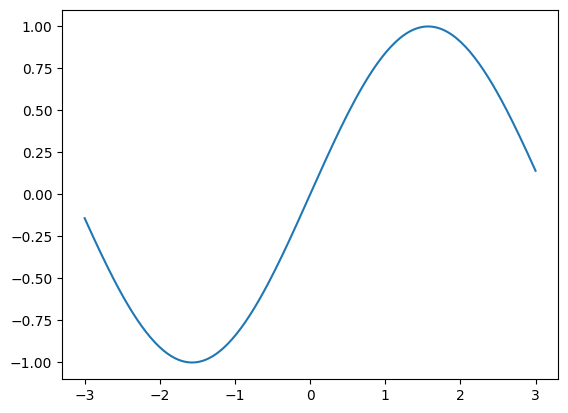

In [ ]:
x = np.linspace(-3, 3, 200).reshape(-1, 1)
y = (np.sin(x)).reshape(-1, 1)

plt.plot(x, y)

In [10]:
def forward(ws, bs, X, act='relu'):
    
    act_fn = Tensor.relu if act == 'relu' else Tensor.sigmoid
    
    batch = Tensor(X, requires_grad=False)
    for i, (w, b) in enumerate(zip(ws, bs)):
        # print(batch.data.shape, w.data.shape, b.data.shape)
        matmul = batch @ w
        batch = (matmul + b.broadcast_to(matmul.data.shape))
        batch = act_fn(batch) if i < len(ws)-1 else batch
    
    return batch

In [11]:
nn_layers = [1, 20, 10, 1]

lr = 0.03

ws = [Tensor(np.random.randn(inp, out)) for inp, out in zip(nn_layers, nn_layers[1:])]
bs = [Tensor(np.random.randn(1, out)) for out in nn_layers[1:]]
act = 'sigmoid'

epochs = 1000

y_tensor = Tensor(y, requires_grad=False)

losses = []

for e in range(epochs):

    y_preds = forward(ws, bs, x, act)

    loss = ((y_preds - y_tensor)**2).sum(axis=0) / y.shape[0]

    loss.backward()

    losses.append(loss.data[0])

    if e % 100 == 0:
        lr *= 0.8

    ws = [w - lr * w.grad for w in ws]
    bs = [b - lr * b.grad for b in bs]

    for w, b in zip(ws, bs):
        w.grad = np.zeros_like(w.data)
        b.grad = np.zeros_like(b.data)

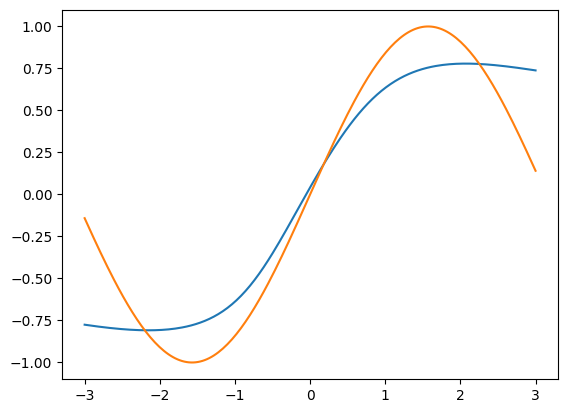

In [12]:
plt.plot(x, y_preds.data)
plt.plot(x, y)